In [1]:
from utils import *
from utils_fmri import * 

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from scipy.stats import kendalltau, pearsonr, ttest_1samp, ttest_rel
from scipy.spatial.distance import cosine

#------------------------- helpers

def mean_dimwise_corr(Y, Yhat):
    Y = np.asarray(Y); Yhat = np.asarray(Yhat)
    return np.nanmean([pearsonr(Y[:, d], Yhat[:, d])[0] for d in range(Y.shape[1])])

def z_against_null(real, null, eps=1e-12):
    null = np.asarray(null, float)
    return (real - null.mean()) / (null.std(ddof=1) + eps)

def p_perm_greater(real, null):
    null = np.asarray(null, float)
    return float((1.0 + np.sum(null >= real)) / (len(null) + 1.0))

def p_perm_less(real, null):
    null = np.asarray(null, float)
    return float((1.0 + np.sum(null <= real)) / (len(null) + 1.0))

def r2_joint(Y, Yhat, eps=1e-12):
    ss_res = np.sum((Y - Yhat) ** 2)
    ss_tot = np.sum((Y - Y.mean(axis=0, keepdims=True)) ** 2)
    return 1.0 - ss_res / (ss_tot + eps)


#------------------------- targets and nulls

def compute_social_locations(character_ids, decisions):
    """
    Per-character cumulative (affiliation, power) locations.
    Returns Y : (T,2) location AFTER applying each decision.
    """
    character_ids = np.asarray(character_ids)
    decisions = np.asarray(decisions)

    T = len(character_ids)
    Y = np.zeros((T, 2), float)

    pos = {}
    for t in range(T):
        c = int(character_ids[t])
        if c not in pos:
            pos[c] = np.zeros(2, float)
        pos[c] = pos[c] + decisions[t]
        Y[t] = pos[c]

    return Y

def permute_decisions_and_recompute_locs(decisions, char_ids, rng=None):
    """
    History-destroying null for trajectories: permute decisions within character,
    then recompute cumulative locations.
    """
    def permute_decisions_within_character(decisions, char_ids, rng=None):
        """
        Permute decision rows within each character (history-destroying),
        preserving marginal distributions per character.
        Returns decisions_perm with same shape.
        """
        if rng is None:
            rng = np.random.default_rng()

        decisions = np.asarray(decisions)
        char_ids = np.asarray(char_ids)

        decisions_perm = np.zeros_like(decisions)
        for ch in np.unique(char_ids):
            idx = np.where(char_ids == ch)[0]
            decisions_perm[idx] = decisions[rng.permutation(idx)]
        return decisions_perm

    decisions_perm = permute_decisions_within_character(decisions, char_ids, rng=rng)
    return compute_social_locations(char_ids, decisions_perm)

from sklearn.model_selection import BaseCrossValidator

class LeaveOneCharacterOut(BaseCrossValidator):
    """
    Leave-One-Character-Out CV.

    Usage:
        cv = LeaveOneCharacterOut()
        for tr, te in cv.split(X, y, groups=char_roles):
            ...

    Notes:
      - `groups` is expected to be the per-trial character id (char_roles).
      - Each fold holds out ALL trials for exactly one character.
      - Order of folds follows np.unique(groups) (sorted unique values).
    """

    def __init__(self, min_train_samples: int = 1):
        self.min_train_samples = int(min_train_samples)

    def get_n_splits(self, X=None, y=None, groups=None):
        if groups is None:
            raise ValueError("LeaveOneCharacterOut requires `groups` (char_roles).")
        g = np.asarray(groups)
        return int(len(np.unique(g)))

    def split(self, X, y=None, groups=None):
        if groups is None:
            raise ValueError("LeaveOneCharacterOut requires `groups` (char_roles).")

        g = np.asarray(groups)
        n = len(g)
        if X is not None and len(X) != n:
            raise ValueError(f"X and groups must have same length; got len(X)={len(X)} len(groups)={n}")
        if y is not None and len(y) != n:
            raise ValueError(f"y and groups must have same length; got len(y)={len(y)} len(groups)={n}")

        unique_chars = np.unique(g)
        all_idx = np.arange(n)

        for ch in unique_chars:
            te = all_idx[g == ch]
            tr = all_idx[g != ch]

            if len(tr) < self.min_train_samples:
                # Rare corner case if there's only one character in data
                continue

            yield tr, te

def make_cv(cv_mode: str, *, n_splits=5, seed=0):
    cv_mode = str(cv_mode).lower()
    if cv_mode in ("random", "kfold_random", "rkf"):
        return KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    if cv_mode in ("sequential", "kfold", "kf"):
        return KFold(n_splits=n_splits, shuffle=False)
    if cv_mode in ("loco", "leave_one_character_out", "leave-one-character-out"):
        return LeaveOneCharacterOut()
    raise ValueError(f"Unknown cv_mode={cv_mode!r}")


#------------------------- load data

subject_data = load_pickle("../analyses/lsa_decision_spm/subject_data_tavares-striatum.pkl")


<h1 align='center'> Computing a semantic subspace </h1>




In [2]:
# generic nested CV classifier
def clf(X, y,
        outer_splits=5,
        inner_splits=3,
        random_state=1):
    """
    Nested CV for decoding affiliation vs power.
    
    Parameters
    ----------
    X : array, shape (T, D)
    y : array, shape (T,), labels {1,2}
    
    Returns
    -------
    mean_acc : float
        Mean outer-CV accuracy with inner hyperparameter tuning.
    outer_accs : list of float
        Accuracy for each outer fold.
    best_Cs : list of float
        Best C chosen in each outer fold.
    """
    outer_cv = StratifiedKFold(n_splits=outer_splits,
                               shuffle=True,
                               random_state=random_state)
    inner_cv = StratifiedKFold(n_splits=inner_splits,
                               shuffle=True,
                               random_state=random_state)

    # search over C only (keep it simple)
    param_grid = {'C': np.logspace(-3, 3, 7)}

    outer_accs = []
    best_Cs = []

    for train_idx, test_idx in outer_cv.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        base_clf = LogisticRegression(
            penalty='l2',
            solver='liblinear',
            max_iter=1000
        )

        gs = GridSearchCV(
            estimator=base_clf,
            param_grid=param_grid,
            cv=inner_cv,
            scoring='accuracy',
            n_jobs=-1
        )
        gs.fit(X_train, y_train)

        best_clf = gs.best_estimator_
        y_pred = best_clf.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        outer_accs.append(acc)
        best_Cs.append(gs.best_params_['C'])

    mean_acc = float(np.mean(outer_accs))
    return mean_acc, outer_accs, best_Cs


## Choice semantics encode dimension

Can't be explained by character identity or time or word count...

In [ ]:
n_perm = 10
rng = np.random.default_rng(123)

results = []

for sub_id, sd in subject_data.items():

    X = sd['embds_noctxt']
    y = sd['behavior']['dimension']

    # ---------------- observed
    mean_acc, outer_accs, best_Cs = clf(X, y)

    # ---------------- null: shuffle labels
    null_accs = []
    for i in range(n_perm):
        y_perm = rng.permutation(y)
        mean_null, _, _ = clf(X, y_perm)
        null_accs.append(mean_null)

    null_accs = np.array(null_accs)

    # empirical p-value: fraction of null >= observed
    p_dim = (np.sum(null_accs >= mean_acc) + 1) / (n_perm + 1)

    results.append({
        'sub_id': sub_id,

        # observed
        'mean_acc': mean_acc,
        'outer_accs': outer_accs,
        'best_Cs': best_Cs,

        # null + p-value
        'null_mean_accs': null_accs.mean(),
        'p_dim': p_dim,
        'n_trials': len(y),
    })

dim_results = pd.DataFrame(results)

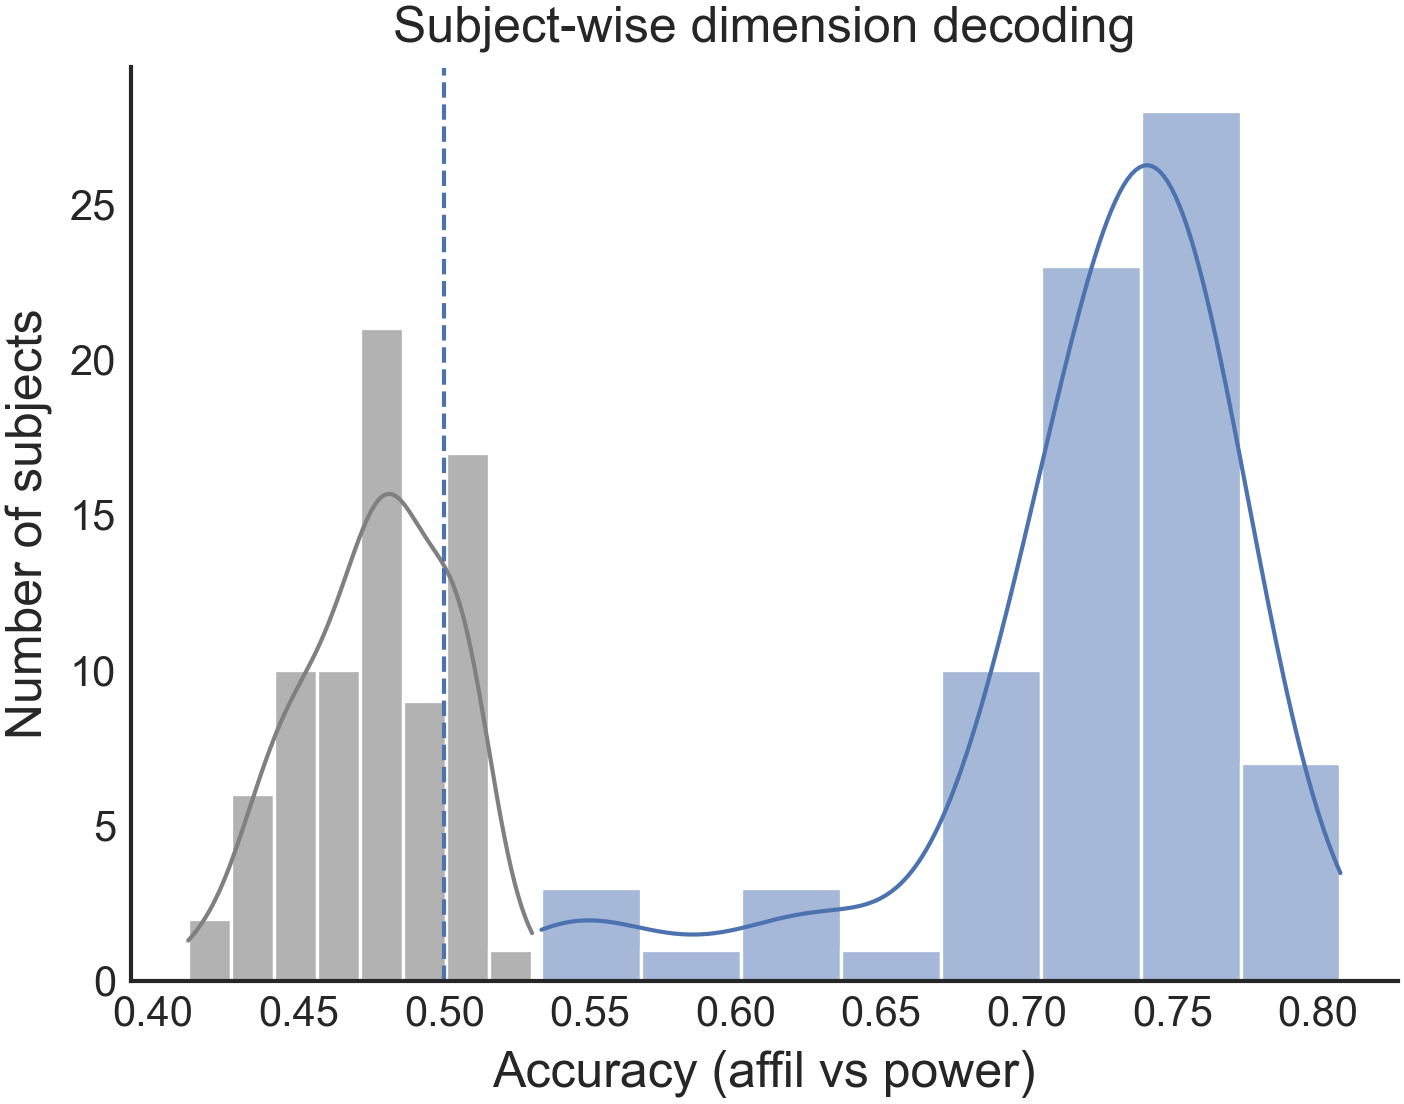

In [53]:
plt.figure(figsize=(5, 4))
sns.histplot(dim_results['mean_acc'].to_numpy(), bins=8, kde=True)
sns.histplot(dim_results['null_mean_accs'].to_numpy(), bins=8, kde=True, color='grey', alpha=0.6)
plt.axvline(0.5, linestyle='--', linewidth=1)
plt.xlabel('Accuracy (affil vs power)')
plt.ylabel('Number of subjects')
plt.title('Subject-wise dimension decoding')
plt.tight_layout()
plt.show()

## Neural geometry is consistent with similarity between choices
this could still be character identity or something trivial - suspicious that its every region right now...

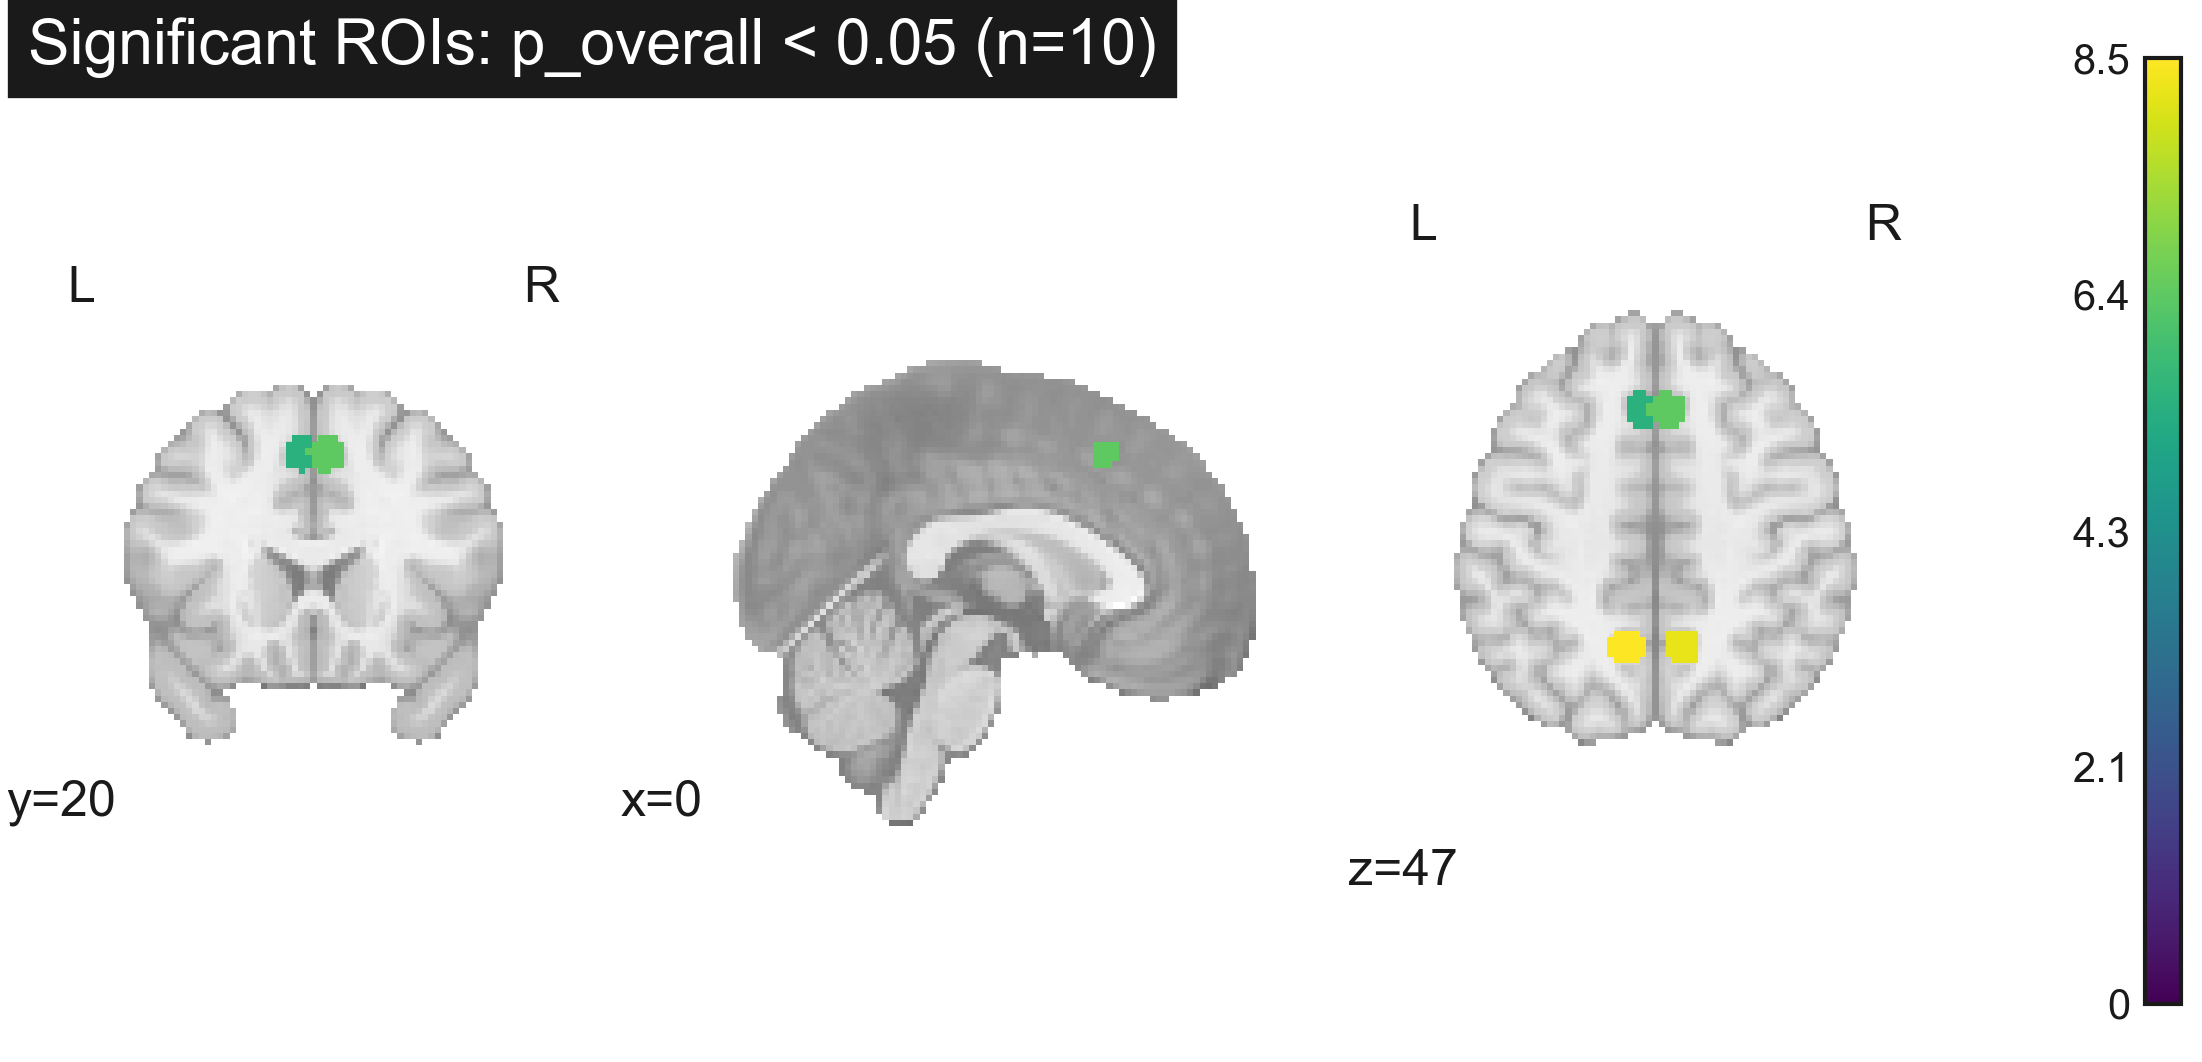

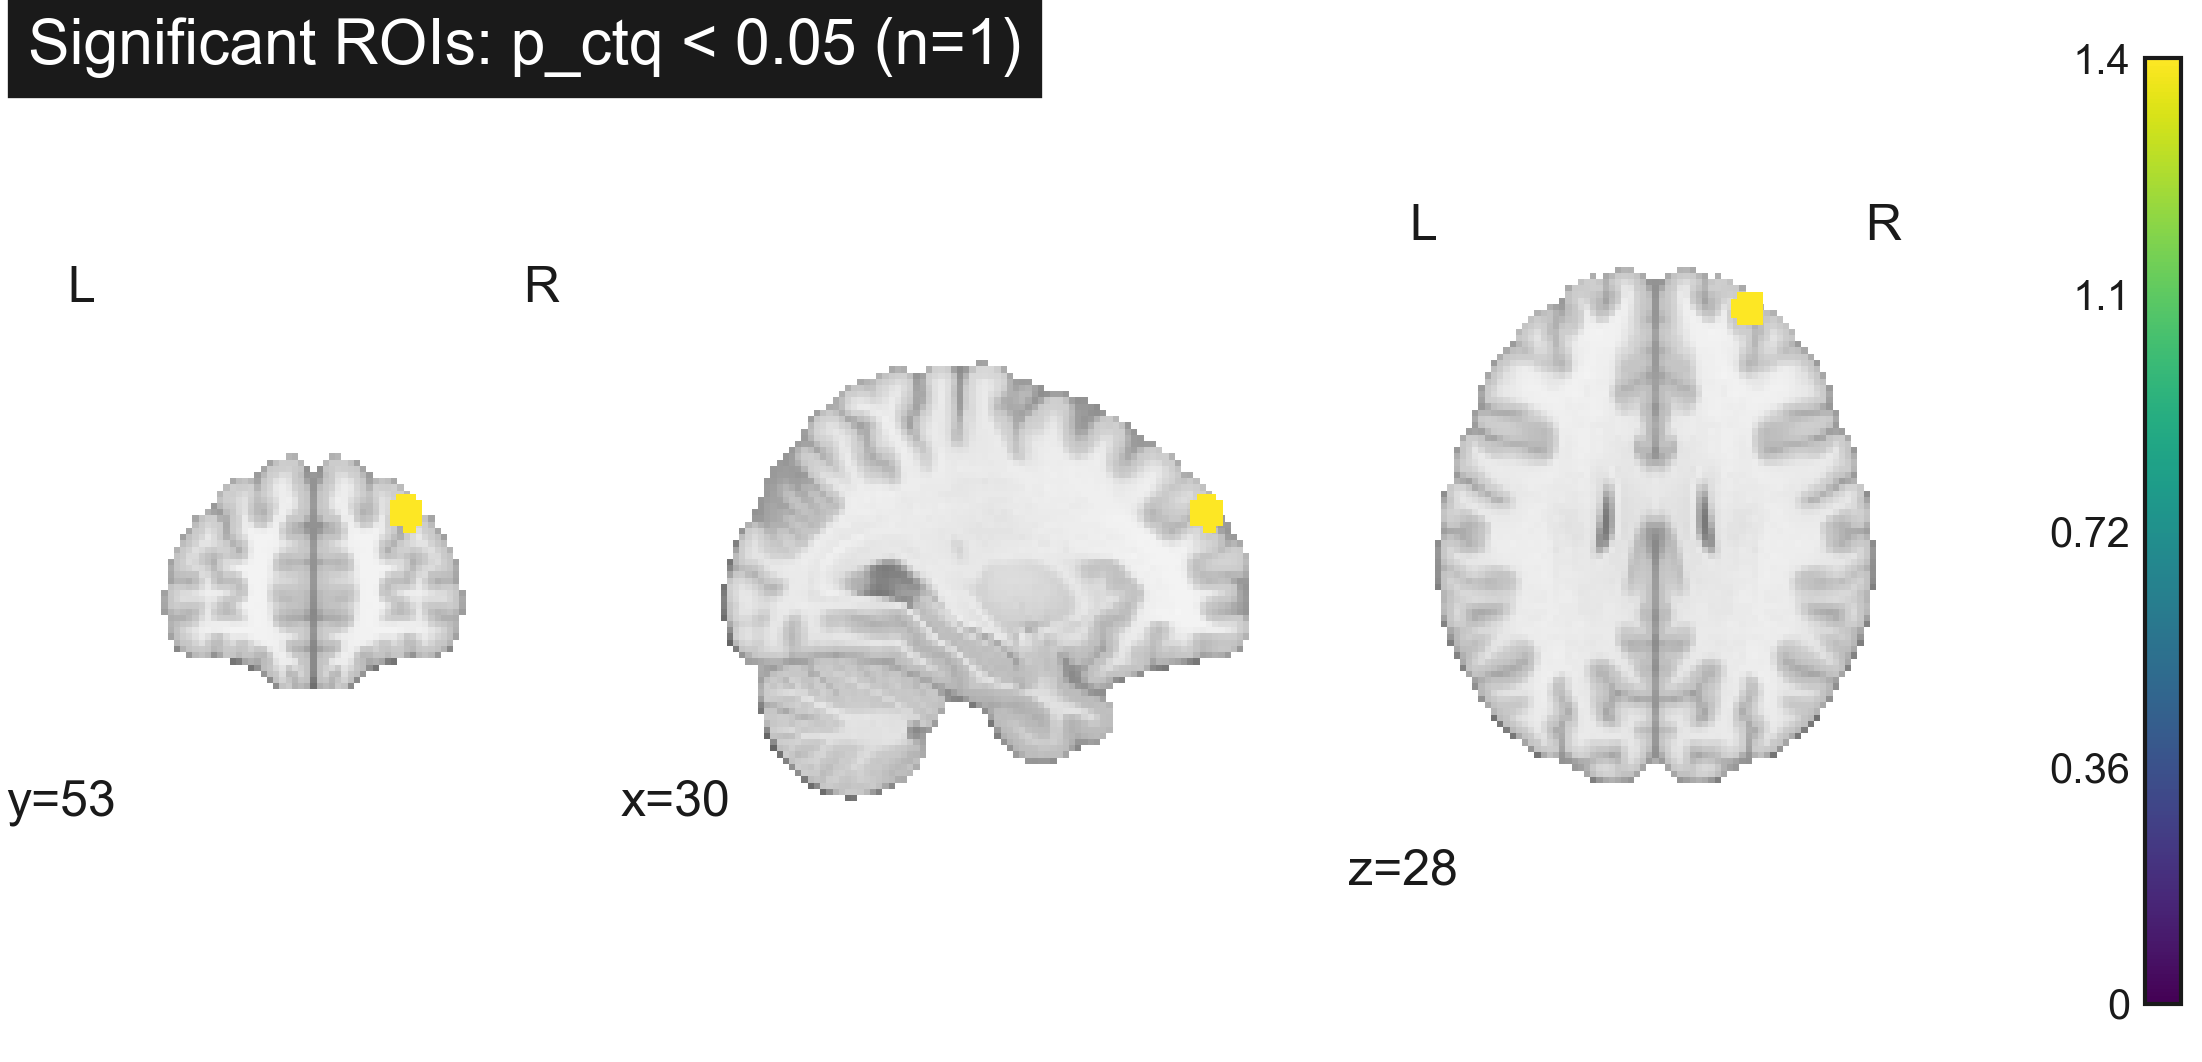

In [ ]:
def run_embedding_rsa(
    all_data,
    emb_key="embds_ctxt"):
    """
    Trialwise RSA:
      Neural distance ~ Cosine(embeddings)
                       + TimeDist + TimeDist^2
                       + (within-character indicators for each character)

    Character controls:
      For each character c in `chars`, adds an RDV that is 1 for pairs where
      both trials are character c, else 0.
    """

    def _pairwise_both_one(indicator_01: np.ndarray) -> np.ndarray:
        v = np.asarray(indicator_01, int).reshape(-1)
        T = v.size
        M = np.logical_and(v[:, None] == 1, v[None, :] == 1).astype(float)
        iu = np.triu_indices(T, k=1)
        return M[iu]

    def _get_roi_code_to_label(sd: dict) -> dict[int, str]:
        """
        Best-effort mapping from ROI integer code -> ROI label string.
        Looks for sd["atlas"]["rois"] (dict) or sd["roi_labels"] (dict).
        Returns {} if not available.
        """
        # Preferred: sd["atlas"]["rois"] where rois is dict[code] = label
        if "atlas" in sd and isinstance(sd["atlas"], dict) and "rois" in sd["atlas"]:
            rois = sd["atlas"]["rois"]
            if isinstance(rois, dict):
                try:
                    return {int(k): str(v) for k, v in rois.items()}
                except Exception:
                    pass

        # Fallback: user-provided mapping
        if "roi_labels" in sd and isinstance(sd["roi_labels"], dict):
            rois = sd["roi_labels"]
            try:
                return {int(k): str(v) for k, v in rois.items()}
            except Exception:
                pass

        return {}

    def _normalize_roi_name(roi_key, code_to_label: dict[int, str]) -> str:
        """
        If roi_key looks like an integer code and we have a mapping, return label.
        Otherwise return roi_key as a string.
        """
        # already a string label
        if isinstance(roi_key, str):
            return roi_key

        # integer-ish atlas code
        try:
            k = int(roi_key)
        except Exception:
            return str(roi_key)

        return code_to_label.get(k, str(k))

    rows = []
    for sub_id, sd in all_data.items():
        if ("behavior" not in sd) or ("roi_betas" not in sd) or (emb_key not in sd):
            continue

        behav = sd["behavior"]
        rois  = sd["roi_betas"]
        Xemb  = np.asarray(sd[emb_key], float)  # (T, D)
        T = len(behav)

        # --- core RDVs (embeddings + time)
        rdvs = compute_flexible_rdvs(
            {
                "emb": Xemb,
                "time": behav["onset"].to_numpy(float),
            },
            metric_dict={
                "emb": "cosine",
                "time": "euclidean",   # -> |Δt|
            },
        )

        time_rdv  = rdvs["time"]
        time2_rdv = time_rdv ** 2

        # --- character identity nuisance RDVs (within-character)
        roles = behav["character_role_num"].to_numpy()
        char_nuis = {}
        chars = (1, 2, 3, 4, 5)
        for c in chars:
            ind = (roles == c).astype(int)  # (T,)
            char_nuis[f"char{c}_within"] = _pairwise_both_one(ind)

        # --- ROI name normalization mapping (code -> label)
        code_to_label = _get_roi_code_to_label(sd)

        for roi_key, betas in rois.items():
            roi_name = _normalize_roi_name(roi_key, code_to_label)
            betas = np.asarray(betas, float)  # (T, V)
            neural_rdv = pdist(betas, metric="correlation")

            nuisance = {"time": time_rdv, "time2": time2_rdv}
            nuisance.update(char_nuis)

            stats = fit_rsa_regression(
                neural_rdv,
                design_rdvs={"emb": rdvs["emb"]},
                nuisance_rdvs=nuisance,
            )

            rows.append({
                "sub_id": sub_id,
                "roi": roi_name,
                "beta": stats["beta_emb"],
                "t_stat": stats["t_emb"],
                "p_val": stats["p_emb"],
                "r2_adj": stats["R2_adj"],
            })

    return pd.DataFrame(rows)

noctxt_df  = run_embedding_rsa(subject_data, emb_key="embds_noctxt")
noctxt_df  = noctxt_df.merge(data, on='sub_id', how='left')
noctxt_res = roi_group_tests(noctxt_df, y_col="beta",  demo_controls=("sex", "fd_mean", "memory_mean"))
plot_sig_rois_from_results(noctxt_res, atlas_pkl, p_col='p_overall');
plot_sig_rois_from_results(noctxt_res, atlas_pkl, p_col='p_dx');
plot_sig_rois_from_results(noctxt_res, atlas_pkl, p_col='p_ctq');

## Finding latent directions
Fit a linear readout from embeddings to social space

The readout defines a 2D subspace in embedding space corresponding to affiliation and power axes


In [23]:
# Ridge probe + geometry

def fit_ridge_subspace(X, Y, alpha=10.0):
    """
    Fit Y ≈ XW + b with ridge.
    Returns W, b in original embedding space.
    """
    X = np.asarray(X)
    Y = np.asarray(Y)

    good = np.isfinite(X).all(1) & np.isfinite(Y).all(1)
    Xg = X[good]
    Yg = Y[good]

    sc = StandardScaler()
    Xz = sc.fit_transform(Xg)

    model = Ridge(alpha=alpha, fit_intercept=True)
    model.fit(Xz, Yg)

    Wz = model.coef_.T
    W = Wz / sc.scale_[:, None]
    b = model.intercept_ - (sc.mean_ / sc.scale_) @ Wz

    return W, b, good

def cv_predict_ridge(X, Y, alphas, outer_splits=5, inner_splits=4):

    def select_alpha_by_cv_corr(X, Y, alphas=(0.1, 1.0, 10.0, 100.0), n_splits=5):
        """
        Choose alpha using CV on (X,Y) and scoring by mean dim-wise Pearson r.
        Uses a simple KFold inner CV (no nested call to cv_predict_ridge).
        """
        X = np.asarray(X); Y = np.asarray(Y)
        n = X.shape[0]
        n_splits_eff = min(n_splits, n)
        if n_splits_eff < 2:
            # fall back to middle alpha if we can't CV
            a0 = alphas[len(alphas) // 2]
            return a0, {a: np.nan for a in alphas}

        kf = KFold(n_splits=n_splits_eff, shuffle=False)
        scores = {}

        for a in alphas:
            Yhat = np.zeros_like(Y, dtype=float)
            for tr, te in kf.split(X):
                W, b, _ = fit_ridge_subspace(X[tr], Y[tr], alpha=a)
                Yhat[te] = project_embeddings(X[te], W, b)
            scores[a] = mean_dimwise_corr(Y, Yhat)

        alpha_best = max(scores, key=lambda a: (-np.inf if np.isnan(scores[a]) else scores[a]))
        return alpha_best, scores


    
    outer = KFold(n_splits=min(outer_splits, len(X)), shuffle=False)
    Yhat = np.zeros_like(Y, dtype=float)

    for tr, te in outer.split(X):
        # inner selection on training only
        alpha_best, _ = select_alpha_by_cv_corr(X[tr], Y[tr], alphas=alphas, n_splits=inner_splits)
        W, b, _ = fit_ridge_subspace(X[tr], Y[tr], alpha=alpha_best)
        Yhat[te] = project_embeddings(X[te], W, b)

    return Yhat

def project_embeddings(X, W, b):
    return np.asarray(X) @ W + b

def rsa_geometry(Y_true, Y_pred):
    """
    Kendall tau between distance matrices.
    """
    Y_true = np.asarray(Y_true); Y_pred = np.asarray(Y_pred)
    if Y_true.shape[0] < 3:
        return np.nan
    D_true = np.linalg.norm(Y_true[:, None] - Y_true[None], axis=-1)
    D_pred = np.linalg.norm(Y_pred[:, None] - Y_pred[None], axis=-1)
    iu = np.triu_indices_from(D_true, k=1)
    return kendalltau(D_true[iu], D_pred[iu]).correlation

def analyze_subject_ridge(
    sd,
    *,
    emb_key="embds_ctxt",
    alphas=(0.1, 1.0, 10.0, 100.0),
    n_splits=5,
    n_perm=30,
    seed=0,
    cv_mode="sequential",  # {"sequential","random","loco"}
):
    """
    Subject-level ridge decoding with configurable CV:
      - cv_mode="sequential": KFold(shuffle=False)  (index-ordered folds; NOT random)
      - cv_mode="random":     KFold(shuffle=True, random_state=seed)
      - cv_mode="loco":       LeaveOneCharacterOut() using sd["char_roles"] as groups

    Assumes you have defined:
      - make_cv(cv_mode, n_splits, seed)
      - LeaveOneCharacterOut
      - fit_ridge_subspace, project_embeddings
      - compute_social_locations, permute_decisions_and_recompute_locs
      - r2_joint, rsa_geometry
    """

    rng = np.random.default_rng(seed)

    # --------------------------------------------------------
    # organize data
    # --------------------------------------------------------

    # embeddings and targets
    X         = np.asarray(sd[emb_key])
    char_ids  = np.asarray(sd["char_roles"])

    # social locations
    decisions = np.asarray(sd["behavior"][["affil_decision", "power_decision"]].values)
    Y_true    = compute_social_locations(char_ids, decisions)

    # --------------------------------------------------------
    # Choose CV splitter
    # --------------------------------------------------------

    n_splits_eff = min(int(n_splits), len(X)) if cv_mode.lower() != "loco" else n_splits
    cv = make_cv(cv_mode, n_splits=n_splits_eff, seed=seed)
    split_kwargs = {}
    if isinstance(cv, LeaveOneCharacterOut):
        split_kwargs["groups"] = char_ids

    # --------------------------------------------------------
    # Alpha selection
    # --------------------------------------------------------

    r2_by_alpha = {}
    for a in alphas:
        Yhat_cv = np.zeros_like(Y_true, dtype=float)
        for tr, te in cv.split(X, Y_true, **split_kwargs):
            W, b, _ = fit_ridge_subspace(X[tr], Y_true[tr], alpha=a)
            Yhat_cv[te] = project_embeddings(X[te], W, b)
        r2_by_alpha[a] = r2_joint(Y_true, Yhat_cv)

    alpha_best = max(r2_by_alpha, key=r2_by_alpha.get)

    # --------------------------------------------------------
    # Out-of-fold predictions with best alpha
    # --------------------------------------------------------

    Yhat = np.zeros_like(Y_true, dtype=float)
    for tr, te in cv.split(X, Y_true, **split_kwargs):
        W, b, _ = fit_ridge_subspace(X[tr], Y_true[tr], alpha=alpha_best)
        Yhat[te] = project_embeddings(X[te], W, b)

    r2_real  = r2_joint(Y_true, Yhat)
    rsa_real = rsa_geometry(Y_true, Yhat)

    # --------------------------------------------------------
    # Baseline: per-character mean, using the SAME CV splits
    # --------------------------------------------------------

    Yhat_base = np.zeros_like(Y_true, dtype=float)
    global_mean = np.nanmean(Y_true, axis=0)

    for tr, te in cv.split(X, Y_true, **split_kwargs):
        # character means on TRAIN only
        means = {}
        for ch in np.unique(char_ids[tr]):
            idx = tr[char_ids[tr] == ch]
            means[int(ch)] = np.nanmean(Y_true[idx], axis=0)

        # predict on TEST
        for i in te:
            ch = int(char_ids[i])
            Yhat_base[i] = means.get(ch, global_mean)

    r2_base   = r2_joint(Y_true, Yhat_base)
    rsa_base  = rsa_geometry(Y_true, Yhat_base)
    delta_r2  = r2_real  - r2_base
    delta_rsa = rsa_real - rsa_base

    # --------------------------------------------------------
    # Axis geometry on full fit
    # --------------------------------------------------------

    W_full = fit_ridge_subspace(X, Y_true, alpha=alpha_best)[0]
    axis_corr_real  = 1 - cosine(W_full[:, 0], W_full[:, 1])
    axis_angle_real = np.degrees(np.arccos(np.clip(axis_corr_real, -1.0, 1.0)))

    # --------------------------------------------------------
    # Prediction null: refit on shuffled-choice trajectories
    # --------------------------------------------------------

    r2_null = np.zeros(n_perm)
    axis_corr_null  = np.zeros(n_perm)
    axis_angle_null = np.zeros(n_perm)

    for i in range(n_perm):
        Yp = permute_decisions_and_recompute_locs(decisions, char_ids, rng)

        Yhat_p = np.zeros_like(Yp, dtype=float)
        for tr, te in cv.split(X, Yp, **split_kwargs):
            Wp, bp, _ = fit_ridge_subspace(X[tr], Yp[tr], alpha=alpha_best)
            Yhat_p[te] = project_embeddings(X[te], Wp, bp)
        r2_null[i] = r2_joint(Yp, Yhat_p)

        Wp_full, _, _ = fit_ridge_subspace(X, Yp, alpha=alpha_best)
        corr_p = 1 - cosine(Wp_full[:, 0], Wp_full[:, 1])
        axis_corr_null[i]  = corr_p
        axis_angle_null[i] = np.degrees(np.arccos(np.clip(corr_p, -1.0, 1.0)))

    # --------------------------------------------------------
    # Geometry null: permute behavioral trajectories only 
    # --------------------------------------------------------

    rsa_null = np.zeros(n_perm)
    for i in range(n_perm):
        Yp = permute_decisions_and_recompute_locs(decisions, char_ids, rng)
        rsa_null[i] = rsa_geometry(Yp, Yhat)

    return {
        "emb_key": emb_key,
        "cv_mode": cv_mode,
        "alpha_best": alpha_best,
        "r2_by_alpha": r2_by_alpha,

        # baseline metrics
        "r2_base": r2_base,
        "rsa_base": rsa_base,
        "delta_r2": delta_r2,
        "delta_rsa": delta_rsa,
        "Y_hat_base": Yhat_base,

        # main metrics
        "r2_real": r2_real,
        "r2_null": r2_null,
        "rsa_real": rsa_real,
        "rsa_null": rsa_null,

        # axis diagnostics
        "axis_corr_real": float(axis_corr_real),
        "axis_angle_real": float(axis_angle_real),
        "axis_corr_null": axis_corr_null,
        "axis_angle_null": axis_angle_null,

        # trajectories
        "Y_true": Y_true,
        "Y_hat": Yhat,
    }

def run_group_ridge(
    subject_data,
    *,
    n_perm=30,
    seed=0,
    n_splits=5,
    cv_mode="sequential",   # {"sequential","random","loco"}
    emb_keys=("embds_ctxt", "embds_noctxt"),
    **kwargs,
):
    """
    Run analyze_subject_ridge for each subject and each embedding key.

    Returns:
        results[sub_id][emb_key] = subject-level dict returned by analyze_subject_ridge
    """
    results = {}
    for sub_id, sd in subject_data.items():
        try:
            sub_res = {}
            for ek in emb_keys:
                sub_res[ek] = analyze_subject_ridge(
                    sd,
                    emb_key=ek,
                    n_perm=n_perm,
                    seed=seed,
                    n_splits=n_splits,
                    cv_mode=cv_mode,
                    **kwargs,
                )
            results[sub_id] = sub_res
        except Exception as e:
            print(f"Skipping {sub_id}: {e}")
    return results

# to compare the different kinds of c.v.
def run_group_ridge_side_by_side(subject_data, *, modes=("random", "loco"), **kwargs):
    return {m: run_group_ridge(subject_data, cv_mode=m, **kwargs) for m in modes}

ridge_results = run_group_ridge_side_by_side(
    subject_data,
    modes=("sequential", "random", "loco"),
    n_perm=30,
    seed=0,
    n_splits=5,
)

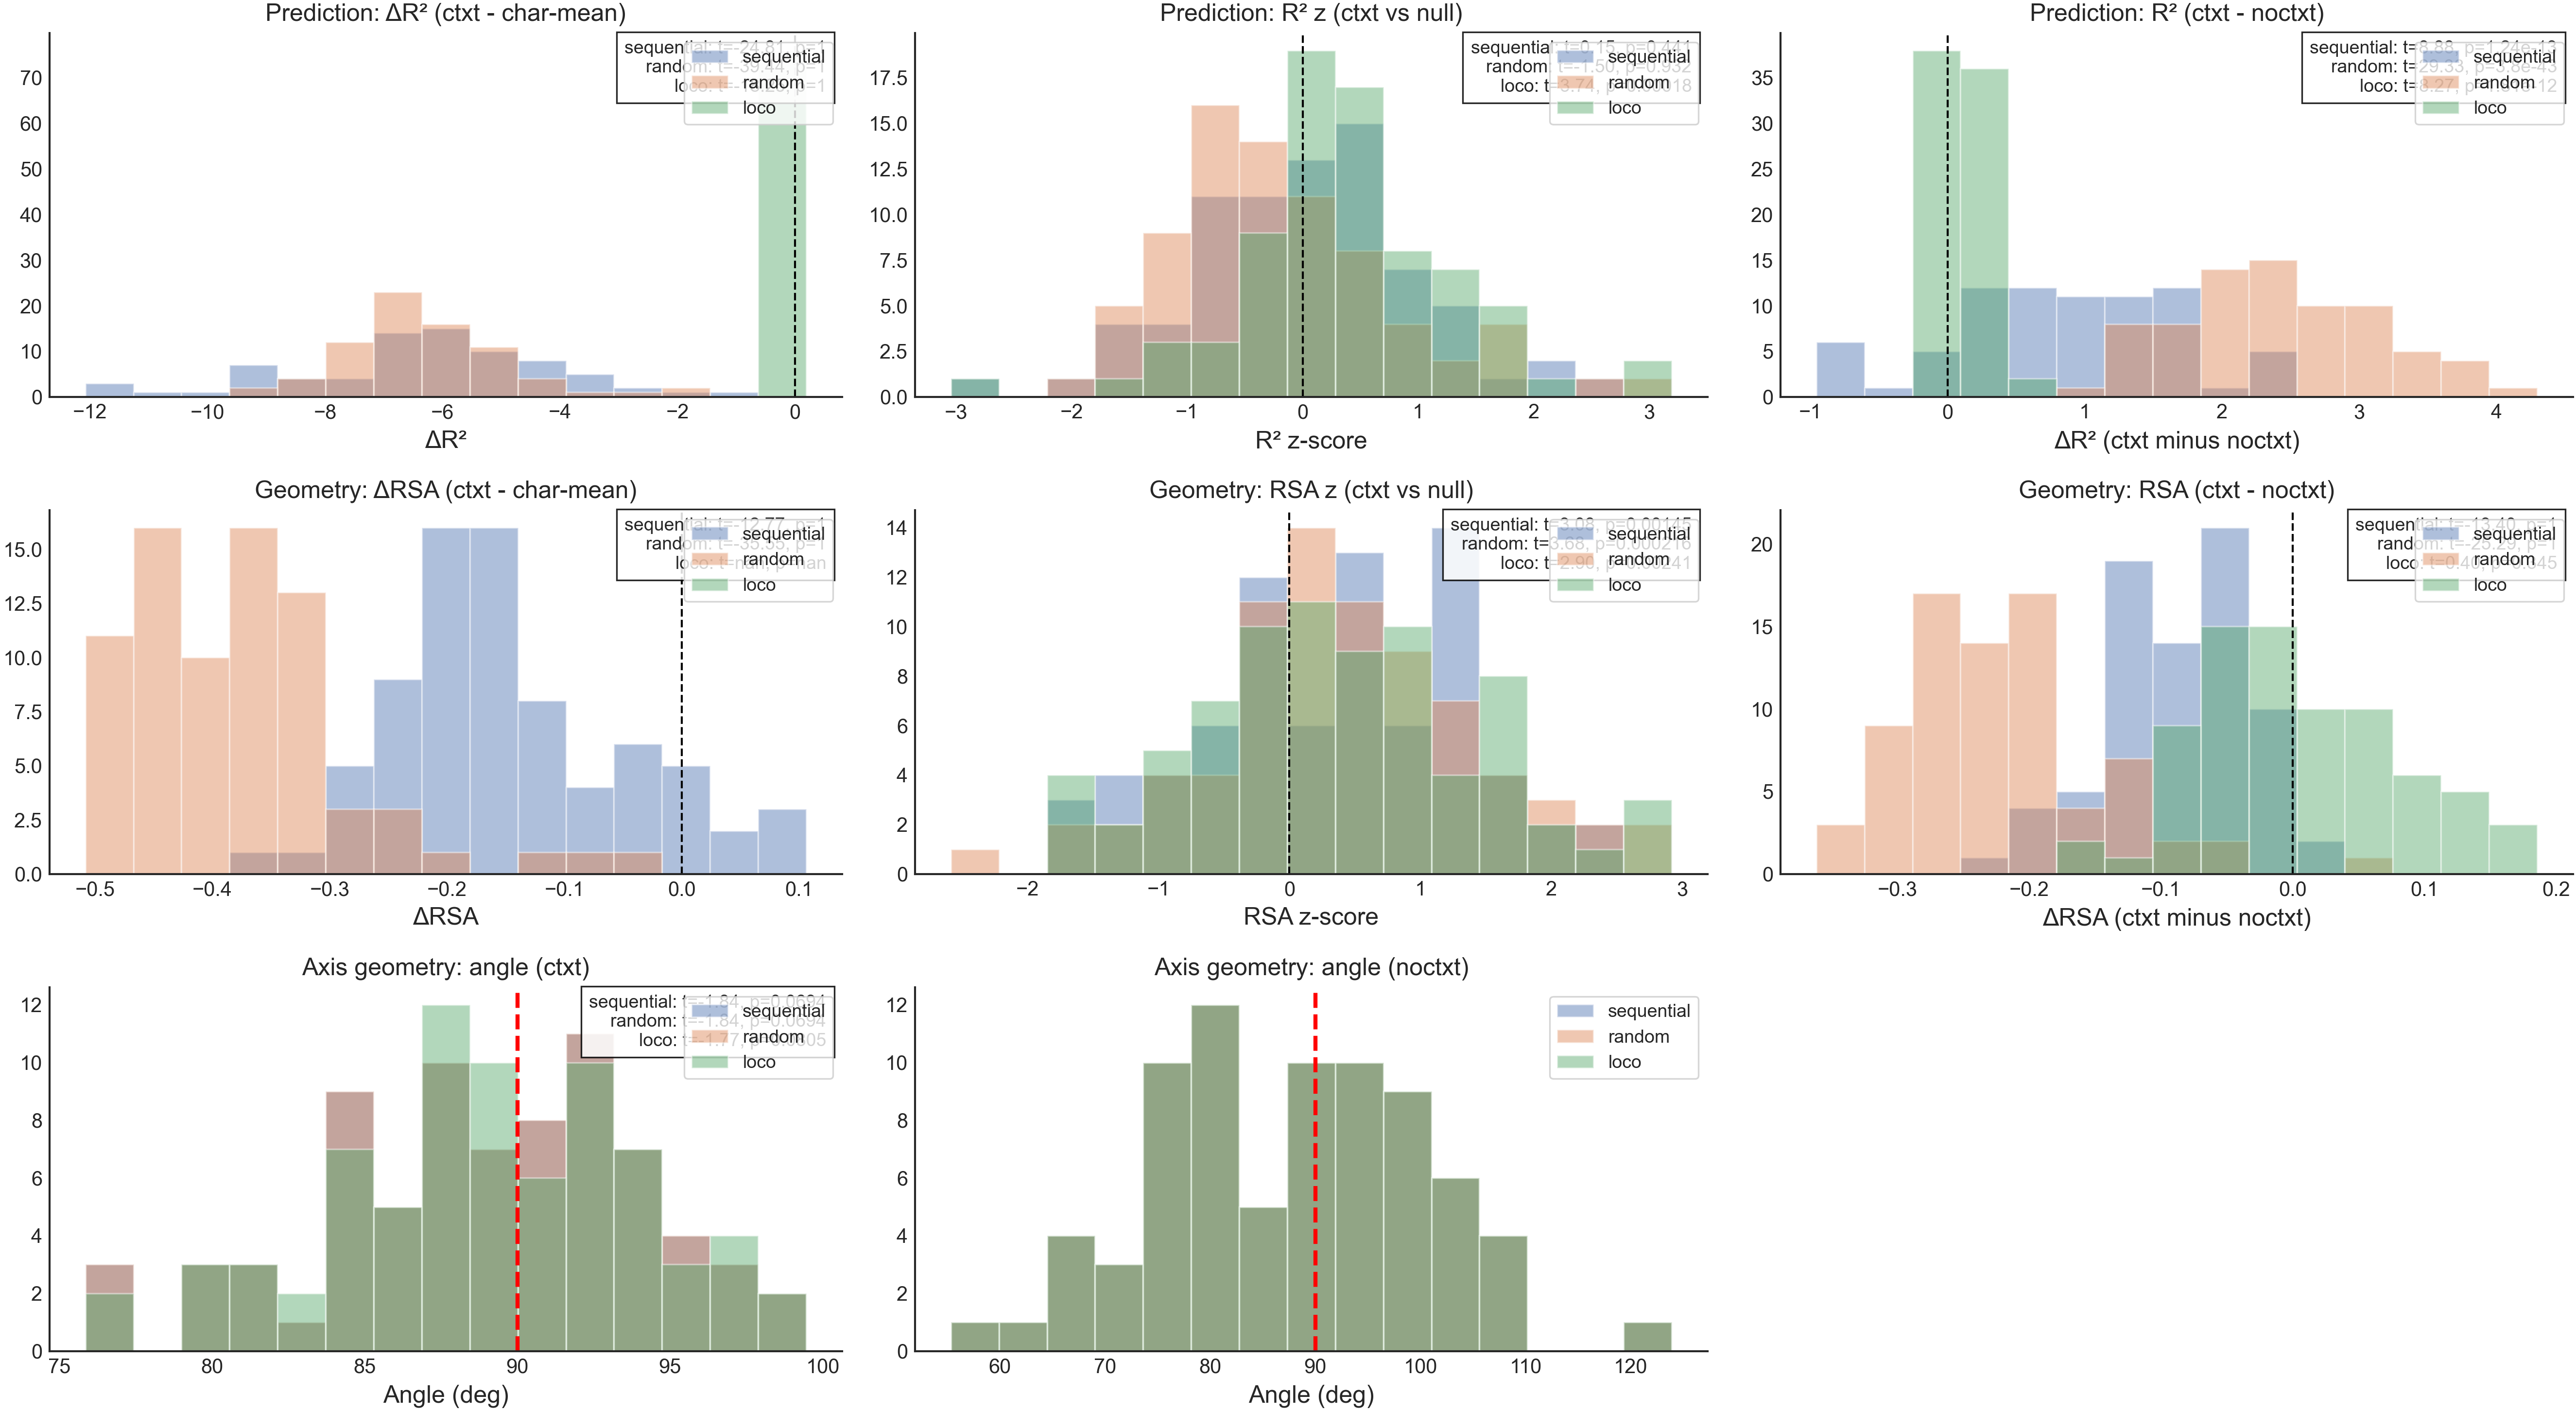

In [24]:
def summarize_group_results(results, eps=1e-12):
    rows = []
    for sub_id, rr in results.items():
        rc = rr["ctxt"]
        rn = rr["noctxt"]

        rows.append({
            "sub_id": sub_id,

            # ----------------------------
            # Prediction (ctxt)
            # ----------------------------
            "r2_base_ctxt":  rc["r2_base"],
            "delta_r2_ctxt": rc["delta_r2"],
            "r2_ctxt":       rc["r2_real"],
            "r2_z_ctxt":     float(z_against_null(rc["r2_real"],  rc["r2_null"],  eps=eps)),

            # ----------------------------
            # Prediction (noctxt)
            # ----------------------------
            "r2_base_noctxt":  rn["r2_base"],
            "delta_r2_noctxt": rn["delta_r2"],
            "r2_noctxt":       rn["r2_real"],
            "r2_z_noctxt":     float(z_against_null(rn["r2_real"], rn["r2_null"], eps=eps)),

            # ctxt benefit (memory)
            "r2_ctxt_minus_noctxt": rc["r2_real"] - rn["r2_real"],
            "delta_r2_ctxt_minus_noctxt": rc["delta_r2"] - rn["delta_r2"],

            # ----------------------------
            # Geometry (ctxt)
            # ----------------------------
            "rsa_base_ctxt":  rc["rsa_base"],
            "delta_rsa_ctxt": rc["delta_rsa"],
            "rsa_ctxt":       rc["rsa_real"],
            "rsa_z_ctxt":     float(z_against_null(rc["rsa_real"],  rc["rsa_null"],  eps=eps)),

            # ----------------------------
            # Geometry (noctxt)
            # ----------------------------
            "rsa_base_noctxt":  rn["rsa_base"],
            "delta_rsa_noctxt": rn["delta_rsa"],
            "rsa_noctxt":       rn["rsa_real"],
            "rsa_z_noctxt":     float(z_against_null(rn["rsa_real"], rn["rsa_null"], eps=eps)),

            # ctxt benefit (memory)
            "rsa_ctxt_minus_noctxt": rc["rsa_real"] - rn["rsa_real"],
            "delta_rsa_ctxt_minus_noctxt": rc["delta_rsa"] - rn["delta_rsa"],

            # Axis diagnostics (only really meaningful for ctxt; but you can inspect both)
            "axis_angle_ctxt":   float(rc["axis_angle_real"]),
            "axis_angle_noctxt": float(rn["axis_angle_real"]),
        })
    return pd.DataFrame(rows)

def summarize_group_results_by_mode(results_by_mode, eps=1e-12):
    """
    Convert nested dict:
        results_by_mode[cv_mode][sub_id]["embds_ctxt"|"embds_noctxt"] -> metrics
    into one tidy dataframe with a cv_mode column.
    """
    rows = []
    for cv_mode, results in results_by_mode.items():
        for sub_id, rr in results.items():
            # Expect emb_keys as in run_group_ridge(): "embds_ctxt" and "embds_noctxt"
            rc = rr["embds_ctxt"]
            rn = rr["embds_noctxt"]

            rows.append({
                "cv_mode": cv_mode,
                "sub_id": sub_id,

                # ----------------------------
                # Prediction (ctxt)
                # ----------------------------
                "r2_base_ctxt":  rc["r2_base"],
                "delta_r2_ctxt": rc["delta_r2"],
                "r2_ctxt":       rc["r2_real"],
                "r2_z_ctxt":     float(z_against_null(rc["r2_real"],  rc["r2_null"],  eps=eps)),

                # ----------------------------
                # Prediction (noctxt)
                # ----------------------------
                "r2_base_noctxt":  rn["r2_base"],
                "delta_r2_noctxt": rn["delta_r2"],
                "r2_noctxt":       rn["r2_real"],
                "r2_z_noctxt":     float(z_against_null(rn["r2_real"], rn["r2_null"], eps=eps)),

                # ctxt benefit (memory)
                "r2_ctxt_minus_noctxt": rc["r2_real"] - rn["r2_real"],
                "delta_r2_ctxt_minus_noctxt": rc["delta_r2"] - rn["delta_r2"],

                # ----------------------------
                # Geometry (ctxt)
                # ----------------------------
                "rsa_base_ctxt":  rc["rsa_base"],
                "delta_rsa_ctxt": rc["delta_rsa"],
                "rsa_ctxt":       rc["rsa_real"],
                "rsa_z_ctxt":     float(z_against_null(rc["rsa_real"],  rc["rsa_null"],  eps=eps)),

                # ----------------------------
                # Geometry (noctxt)
                # ----------------------------
                "rsa_base_noctxt":  rn["rsa_base"],
                "delta_rsa_noctxt": rn["delta_rsa"],
                "rsa_noctxt":       rn["rsa_real"],
                "rsa_z_noctxt":     float(z_against_null(rn["rsa_real"], rn["rsa_null"], eps=eps)),

                # ctxt benefit (memory)
                "rsa_ctxt_minus_noctxt": rc["rsa_real"] - rn["rsa_real"],
                "delta_rsa_ctxt_minus_noctxt": rc["delta_rsa"] - rn["delta_rsa"],

                # Axis diagnostics
                "axis_angle_ctxt":   float(rc["axis_angle_real"]),
                "axis_angle_noctxt": float(rn["axis_angle_real"]),
            })

    return pd.DataFrame(rows)

def compute_stats_for_mode(df_mode):
    """
    Mirrors your exact inferential tests, but for a single cv_mode subset.
    Returns a dict of (t, p) pairs.
    """
    out = {}

    out["dr2_ctxt"] = ttest_1samp(df_mode["delta_r2_ctxt"], popmean=0, alternative="greater")
    out["r2z_ctxt"] = ttest_1samp(df_mode["r2_z_ctxt"],     popmean=0, alternative="greater")
    out["r2_mem"]   = ttest_rel(df_mode["r2_ctxt"], df_mode["r2_noctxt"], alternative="greater")

    out["drsa_ctxt"] = ttest_1samp(df_mode["delta_rsa_ctxt"], popmean=0, alternative="greater")
    out["rsaz_ctxt"] = ttest_1samp(df_mode["rsa_z_ctxt"],     popmean=0, alternative="greater")
    out["rsa_mem"]   = ttest_rel(df_mode["rsa_ctxt"], df_mode["rsa_noctxt"], alternative="greater")

    # two-sided by default (same as your original)
    out["ang_ctxt"]  = ttest_1samp(df_mode["axis_angle_ctxt"], popmean=90)

    return out

def _overlay_hist(ax, data_by_mode, *, bins=15, xlabel="", title="", vline=0, vline_kwargs=None):
    """
    Overlay histograms for each cv_mode.
    """
    if vline_kwargs is None:
        vline_kwargs = dict(color="black", linestyle="--", linewidth=1)

    # consistent bin edges across modes
    all_vals = np.concatenate([np.asarray(v, float) for v in data_by_mode.values()])
    all_vals = all_vals[np.isfinite(all_vals)]
    if all_vals.size == 0:
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.text(0.5, 0.5, "No finite values", ha="center", va="center", transform=ax.transAxes)
        return

    edges = np.histogram_bin_edges(all_vals, bins=bins)

    # plot each mode
    for mode, vals in data_by_mode.items():
        vals = np.asarray(vals, float)
        vals = vals[np.isfinite(vals)]
        ax.hist(vals, bins=edges, alpha=0.45, label=mode, density=False)

    ax.axvline(vline, **vline_kwargs)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.legend(frameon=True, fontsize=9)

# ----------------------------
# Main: build ridge_df with cv_mode + run stats + plot
# ----------------------------

ridge_df_all = summarize_group_results_by_mode(ridge_results)
modes = list(ridge_df_all["cv_mode"].unique())
stats_by_mode = {m: compute_stats_for_mode(ridge_df_all[ridge_df_all["cv_mode"] == m]) for m in modes}

# ----------------------------
# Plot
# ----------------------------

fig, axs = plt.subplots(3, 3, figsize=(18, 10), sharey=False)

# Row 1: Prediction
_overlay_hist(
    axs[0, 0],
    {m: ridge_df_all.loc[ridge_df_all["cv_mode"] == m, "delta_r2_ctxt"].values for m in modes},
    bins=15,
    xlabel="ΔR²",
    title="Prediction: ΔR² (ctxt - char-mean)",
    vline=0,
)

_overlay_hist(
    axs[0, 1],
    {m: ridge_df_all.loc[ridge_df_all["cv_mode"] == m, "r2_z_ctxt"].values for m in modes},
    bins=15,
    xlabel="R² z-score",
    title="Prediction: R² z (ctxt vs null)",
    vline=0,
)

_overlay_hist(
    axs[0, 2],
    {m: ridge_df_all.loc[ridge_df_all["cv_mode"] == m, "r2_ctxt_minus_noctxt"].values for m in modes},
    bins=15,
    xlabel="ΔR² (ctxt minus noctxt)",
    title="Prediction: R² (ctxt - noctxt)",
    vline=0,
)

# Row 2: Geometry
_overlay_hist(
    axs[1, 0],
    {m: ridge_df_all.loc[ridge_df_all["cv_mode"] == m, "delta_rsa_ctxt"].values for m in modes},
    bins=15,
    xlabel="ΔRSA",
    title="Geometry: ΔRSA (ctxt - char-mean)",
    vline=0,
)

_overlay_hist(
    axs[1, 1],
    {m: ridge_df_all.loc[ridge_df_all["cv_mode"] == m, "rsa_z_ctxt"].values for m in modes},
    bins=15,
    xlabel="RSA z-score",
    title="Geometry: RSA z (ctxt vs null)",
    vline=0,
)

_overlay_hist(
    axs[1, 2],
    {m: ridge_df_all.loc[ridge_df_all["cv_mode"] == m, "rsa_ctxt_minus_noctxt"].values for m in modes},
    bins=15,
    xlabel="ΔRSA (ctxt minus noctxt)",
    title="Geometry: RSA (ctxt - noctxt)",
    vline=0,
)

# Row 3: Axis angles
_overlay_hist(
    axs[2, 0],
    {m: ridge_df_all.loc[ridge_df_all["cv_mode"] == m, "axis_angle_ctxt"].values for m in modes},
    bins=15,
    xlabel="Angle (deg)",
    title="Axis geometry: angle (ctxt)",
    vline=90,
    vline_kwargs=dict(color="red", linestyle="--", linewidth=2),
)

_overlay_hist(
    axs[2, 1],
    {m: ridge_df_all.loc[ridge_df_all["cv_mode"] == m, "axis_angle_noctxt"].values for m in modes},
    bins=15,
    xlabel="Angle (deg)",
    title="Axis geometry: angle (noctxt)",
    vline=90,
    vline_kwargs=dict(color="red", linestyle="--", linewidth=2),
)

axs[2, 2].axis("off")

# Optional: annotate stats per mode in each relevant panel (compact)
def _fmt_ttest(res):
    return f"t={res.statistic:.2f}, p={res.pvalue:.3g}"

# Put a compact multi-line stats box on a few key panels (ctxt tests)
box_panels = {
    (0, 0): "dr2_ctxt",
    (0, 1): "r2z_ctxt",
    (0, 2): "r2_mem",
    (1, 0): "drsa_ctxt",
    (1, 1): "rsaz_ctxt",
    (1, 2): "rsa_mem",
    (2, 0): "ang_ctxt",
}

for (r, c), key in box_panels.items():
    ax = axs[r, c]
    lines = [f"{m}: {_fmt_ttest(stats_by_mode[m][key])}" for m in modes]
    ax.text(
        0.98, 0.98, "\n".join(lines),
        transform=ax.transAxes, ha="right", va="top",
        bbox=dict(facecolor="white", alpha=0.85, edgecolor="black"),
        fontsize=9
    )

for ax in axs.flat:
    if hasattr(ax, "grid"):
        ax.grid(False)

plt.tight_layout()
plt.show()